# A year of crime in Chicago, in plain SQL

Every crime reported to the Chicago Police Department in 2023 (**263,850 incidents**), explored with SQL only: a 7-day moving average with a window frame, arrest rates with conditional aggregation, `ROW_NUMBER` to find each neighbourhood's most common crime, a z-score built from window functions to flag unusual days and a gaps-and-islands query for the longest hot streaks. Python only runs the queries and draws the charts.

**Data:** [Crimes - 2001 to Present](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2) from the City of Chicago open data portal. Run `python build_db.py` once to download 2023 (about 30 MB) into a SQLite database, then point `CHICAGO_DB` at that file.

**Reading the data.** These are *reported* incidents, so the numbers reflect reporting and policing as well as crime itself. There are no population figures here, which is why neighbourhoods are compared by raw counts.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("CHICAGO_DB", "chicago.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,community_areas,77
1,crimes,263850


## 1. What does the year look like day by day?

Daily incident counts, with a **7-day moving average** from a window frame (`ROWS BETWEEN 6 PRECEDING AND CURRENT ROW`) to smooth out the weekly rhythm.

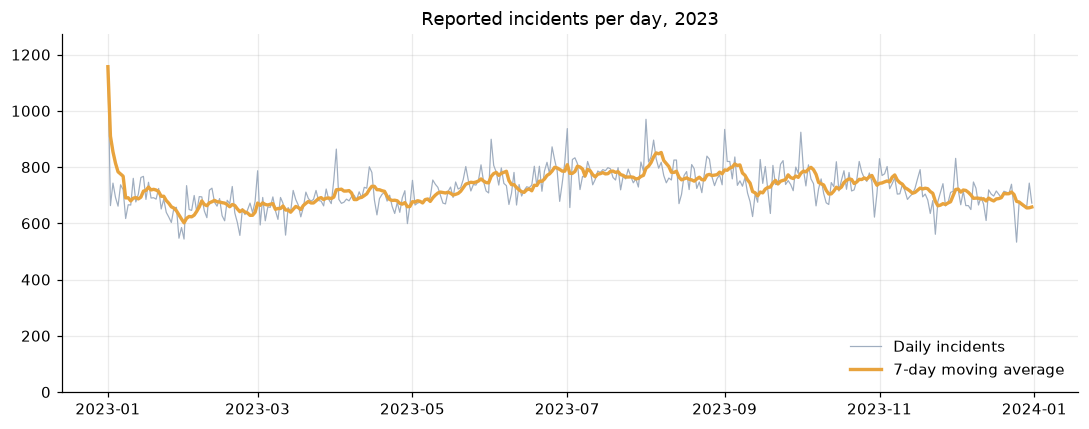

count     365.0
mean      723.0
std        70.0
min       533.0
25%       676.0
50%       718.0
75%       761.0
max      1157.0
Name: incidents, dtype: float64

In [3]:
daily = q("""
WITH daily AS (
    SELECT substr(date, 1, 10) AS day, COUNT(*) AS incidents
    FROM crimes
    GROUP BY day
)
SELECT day, incidents,
       ROUND(AVG(incidents) OVER (ORDER BY day ROWS BETWEEN 6 PRECEDING AND CURRENT ROW), 1) AS moving_avg_7d
FROM daily
ORDER BY day
""")

x = pd.to_datetime(daily.day)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, daily.incidents, color=GREY, lw=0.8, label="Daily incidents")
ax.plot(x, daily.moving_avg_7d, color=AMBER, lw=2.2, label="7-day moving average")
ax.set_ylim(0, daily.incidents.max() * 1.1)
ax.set_title("Reported incidents per day, 2023")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()
daily.incidents.describe().round(0)

## 2. What kinds of crime are most common, and how often do they end in an arrest?

Grouping by crime type with conditional aggregation: the average of the 0/1 `arrest` and `domestic` flags is the arrest rate and the domestic share, and `SUM(COUNT(*)) OVER ()` gives each type's share of all incidents.

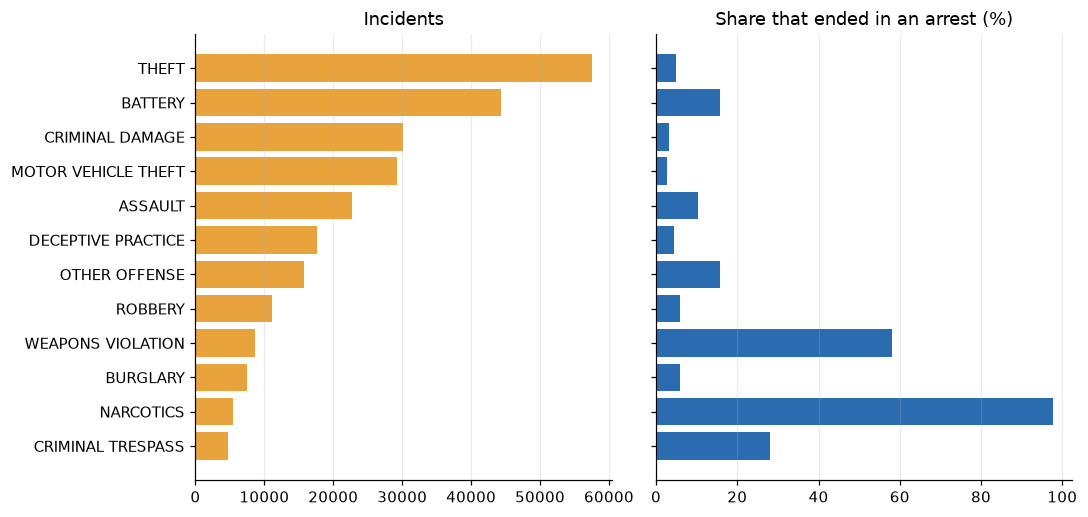

,crime_type,incidents,share_pct,arrest_pct,domestic_pct
0,THEFT,57527,21.8,5.0,4.7
1,BATTERY,44303,16.8,15.8,54.1
2,CRIMINAL DAMAGE,30098,11.4,3.1,13.3
3,MOTOR VEHICLE THEFT,29256,11.1,2.7,1.2
4,ASSAULT,22643,8.6,10.3,28.3
5,DECEPTIVE PRACTICE,17660,6.7,4.3,1.5
6,OTHER OFFENSE,15747,6.0,15.8,37.1
7,ROBBERY,11059,4.2,6.0,2.0
8,WEAPONS VIOLATION,8609,3.3,58.0,0.5
9,BURGLARY,7494,2.8,6.0,3.7


In [4]:
types = q("""
SELECT primary_type                                          AS crime_type,
       COUNT(*)                                              AS incidents,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)    AS share_pct,
       ROUND(100.0 * AVG(arrest), 1)                         AS arrest_pct,
       ROUND(100.0 * AVG(domestic), 1)                       AS domestic_pct
FROM crimes
GROUP BY primary_type
ORDER BY incidents DESC
LIMIT 12
""")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), sharey=True)
y = range(len(types))
axes[0].barh(y, types.incidents, color=AMBER)
axes[0].set_yticks(list(y), types.crime_type)
axes[0].invert_yaxis()
axes[0].set_title("Incidents")
axes[1].barh(y, types.arrest_pct, color=BLUE)
axes[1].set_title("Share that ended in an arrest (%)")
for ax in axes:
    ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()
types

## 3. When do crimes happen?

`strftime('%w')` and `strftime('%H')` split every timestamp into weekday and hour. Many reports carry a default midnight time when the exact time is unknown, which shows up as a bright first column.

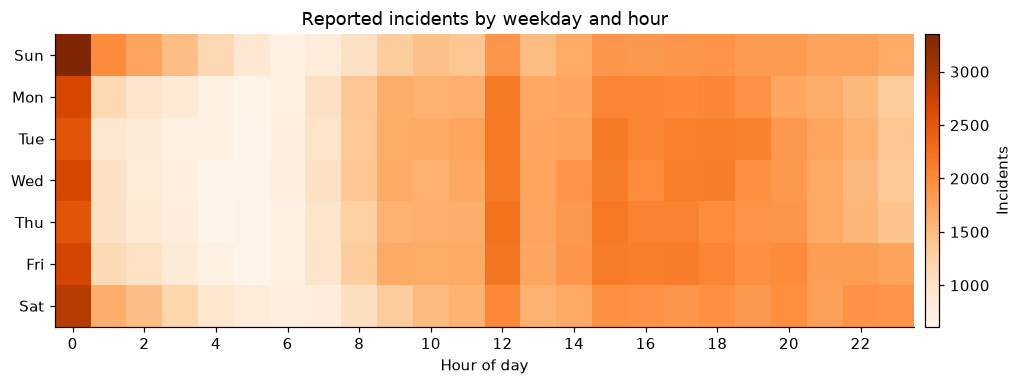

In [5]:
hours = q("""
SELECT CAST(strftime('%w', date) AS INT) AS weekday,    -- 0 = Sunday
       CAST(strftime('%H', date) AS INT) AS hour,
       COUNT(*)                          AS incidents
FROM crimes
GROUP BY weekday, hour
ORDER BY weekday, hour
""")

grid = hours.pivot(index="weekday", columns="hour", values="incidents").fillna(0)
fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(grid.values, cmap="Oranges", aspect="auto")
ax.set_yticks(range(7), ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"])
ax.set_xticks(range(0, 24, 2), range(0, 24, 2))
ax.set_xlabel("Hour of day")
ax.set_title("Reported incidents by weekday and hour")
ax.grid(False)
fig.colorbar(im, ax=ax, label="Incidents", pad=0.01)
fig.tight_layout()
plt.show()

## 4. Which neighbourhoods report the most, and what is their typical crime?

`ROW_NUMBER() OVER (PARTITION BY community_area ORDER BY n DESC)` finds the most common crime type inside each of the 77 community areas, and `RANK()` orders the areas by their total.

In [6]:
areas = q("""
WITH area_type AS (
    SELECT community_area, primary_type, COUNT(*) AS n
    FROM crimes
    WHERE community_area IS NOT NULL
    GROUP BY community_area, primary_type
),
ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY community_area ORDER BY n DESC) AS rn,
           SUM(n)       OVER (PARTITION BY community_area)                 AS total
    FROM area_type
)
SELECT RANK() OVER (ORDER BY r.total DESC)  AS rank,
       a.community,
       r.total                              AS incidents,
       r.primary_type                       AS most_common_type,
       ROUND(100.0 * r.n / r.total, 1)      AS its_share_pct
FROM ranked r
JOIN community_areas a ON a.area_number = r.community_area
WHERE r.rn = 1
ORDER BY r.total DESC
LIMIT 10
""")

areas

,rank,community,incidents,most_common_type,its_share_pct
0,1,Austin,12701,BATTERY,20.3
1,2,Near North Side,11199,THEFT,38.7
2,3,Near West Side,10424,THEFT,30.5
3,4,Loop,8810,THEFT,39.3
4,5,South Shore,8794,BATTERY,20.0
5,6,West Town,8025,THEFT,31.3
6,7,North Lawndale,7151,BATTERY,22.4
7,8,Humboldt Park,6998,BATTERY,17.6
8,9,Auburn Gresham,6893,BATTERY,19.6
9,10,Greater Grand Crossing,6766,BATTERY,20.6


## 5. Where do thefts happen?

Filtering to one crime type and ranking `location_description` with a window total shows what the typical setting is.

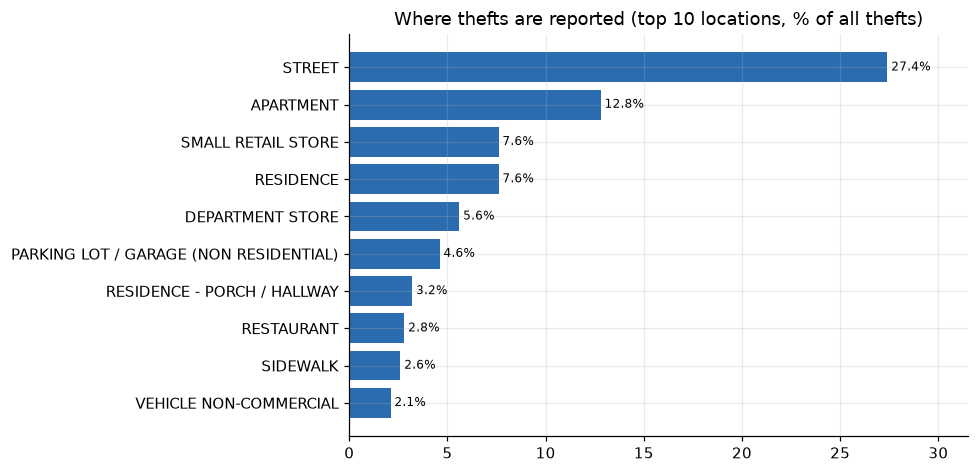

,location,thefts,share_pct,cumulative_pct
0,STREET,15760,27.4,27.4
1,APARTMENT,7376,12.8,40.2
2,SMALL RETAIL STORE,4397,7.6,47.9
3,RESIDENCE,4376,7.6,55.5
4,DEPARTMENT STORE,3227,5.6,61.1
5,PARKING LOT / GARAGE (NON RESIDENTIAL),2649,4.6,65.7
6,RESIDENCE - PORCH / HALLWAY,1827,3.2,68.9
7,RESTAURANT,1583,2.8,71.6
8,SIDEWALK,1471,2.6,74.2
9,VEHICLE NON-COMMERCIAL,1205,2.1,76.3


In [7]:
theft = q("""
SELECT location_description                                      AS location,
       COUNT(*)                                                  AS thefts,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)        AS share_pct,
       ROUND(100.0 * SUM(COUNT(*)) OVER (ORDER BY COUNT(*) DESC)
                   / SUM(COUNT(*)) OVER (), 1)                   AS cumulative_pct
FROM crimes
WHERE primary_type = 'THEFT' AND location_description IS NOT NULL
GROUP BY location_description
ORDER BY thefts DESC
LIMIT 10
""")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(theft.location[::-1], theft.share_pct[::-1], color=BLUE)
for y, v in enumerate(theft.share_pct[::-1]):
    ax.text(v + 0.2, y, f"{v}%", va="center", fontsize=8)
ax.set_xlim(0, theft.share_pct.max() * 1.15)
ax.set_title("Where thefts are reported (top 10 locations, % of all thefts)")
fig.tight_layout()
plt.show()
theft

## 6. Which days were unusual?

SQLite has no standard deviation, but window functions can build one: `AVG(x) OVER ()` and `AVG(x*x) OVER ()` give the variance as `E[x^2] - E[x]^2`. The z-score then says how many standard deviations a day sits from the average, in either direction.

In [8]:
spikes = q("""
WITH daily AS (
    SELECT substr(date, 1, 10) AS day, COUNT(*) AS incidents
    FROM crimes
    GROUP BY day
),
stats AS (
    SELECT day, incidents,
           AVG(incidents)              OVER () AS mean,
           AVG(incidents * incidents)  OVER () AS mean_sq
    FROM daily
),
scored AS (
    SELECT day, incidents, mean,
           (incidents - mean) / sqrt(mean_sq - mean * mean) AS z
    FROM stats
)
SELECT day,
       CASE strftime('%w', day) WHEN '0' THEN 'Sun' WHEN '1' THEN 'Mon' WHEN '2' THEN 'Tue'
                                WHEN '3' THEN 'Wed' WHEN '4' THEN 'Thu' WHEN '5' THEN 'Fri' ELSE 'Sat' END AS weekday,
       incidents,
       ROUND(mean)       AS typical_day,
       ROUND(z, 2)       AS z_score
FROM scored
WHERE ABS(z) >= 2.5
ORDER BY ABS(z) DESC
LIMIT 10
""")

spikes

,day,weekday,incidents,typical_day,z_score
0,2023-01-01,Sun,1157,723.0,6.24
1,2023-08-01,Tue,970,723.0,3.55
2,2023-07-01,Sat,937,723.0,3.08
3,2023-09-01,Fri,934,723.0,3.04
4,2023-10-01,Sun,924,723.0,2.89
5,2023-12-25,Mon,533,723.0,-2.73
6,2023-01-31,Tue,544,723.0,-2.57
7,2023-06-01,Thu,899,723.0,2.53
8,2023-01-29,Sun,547,723.0,-2.53


## 7. Why are the 1st of the month so busy?

Five of the six unusually busy days in the previous query are the first of a month. Splitting each crime type's daily average into "1st of the month" and "any other day" (New Year's Day left out) shows which types drive the difference, using conditional `AVG(CASE ...)`.

In [9]:
first = q("""
WITH daily AS (
    SELECT substr(date, 1, 10) AS day, primary_type, COUNT(*) AS n
    FROM crimes
    WHERE substr(date, 1, 10) <> '2023-01-01'
    GROUP BY day, primary_type
),
split AS (
    SELECT primary_type,
           AVG(CASE WHEN substr(day, 9, 2) =  '01' THEN n END) AS on_the_1st,
           AVG(CASE WHEN substr(day, 9, 2) <> '01' THEN n END) AS other_days
    FROM daily
    GROUP BY primary_type
)
SELECT primary_type                         AS crime_type,
       ROUND(on_the_1st)                    AS avg_on_the_1st,
       ROUND(other_days)                    AS avg_other_days,
       ROUND(on_the_1st - other_days)       AS extra_per_day,
       ROUND(on_the_1st / other_days, 1)    AS ratio
FROM split
WHERE other_days >= 20
ORDER BY extra_per_day DESC
LIMIT 6
""")

first

,crime_type,avg_on_the_1st,avg_other_days,extra_per_day,ratio
0,DECEPTIVE PRACTICE,113.0,46.0,67.0,2.5
1,THEFT,186.0,157.0,29.0,1.2
2,OTHER OFFENSE,55.0,43.0,12.0,1.3
3,BATTERY,129.0,121.0,8.0,1.1
4,WEAPONS VIOLATION,27.0,23.0,3.0,1.1
5,ASSAULT,64.0,62.0,2.0,1.0


## 8. How long did the hot streaks last?

A **gaps-and-islands** query: the median day is found with `ROW_NUMBER`, every day is flagged as above or not above it, and the difference between the overall day number and the day number *within* its flag stays constant for as long as a streak lasts, so grouping by it collapses each streak into one row.

In [10]:
streaks = q("""
WITH daily AS (
    SELECT substr(date, 1, 10) AS day, COUNT(*) AS incidents
    FROM crimes
    GROUP BY day
),
ordered AS (
    SELECT incidents,
           ROW_NUMBER() OVER (ORDER BY incidents) AS rn,
           COUNT(*)     OVER ()                   AS n
    FROM daily
),
median AS (SELECT incidents AS m FROM ordered WHERE rn = (n + 1) / 2),
flagged AS (
    SELECT day, incidents,
           incidents > (SELECT m FROM median)      AS above,
           ROW_NUMBER() OVER (ORDER BY day)        AS day_no
    FROM daily
),
numbered AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY above ORDER BY day) AS flag_no
    FROM flagged
)
SELECT MIN(day)              AS first_day,
       MAX(day)              AS last_day,
       COUNT(*)              AS days_in_a_row,
       ROUND(AVG(incidents)) AS avg_incidents
FROM numbered
WHERE above = 1
GROUP BY day_no - flag_no
ORDER BY days_in_a_row DESC, first_day
LIMIT 6
""")

streaks

,first_day,last_day,days_in_a_row,avg_incidents
0,2023-07-03,2023-08-13,42,790.0
1,2023-08-24,2023-09-09,17,786.0
2,2023-09-20,2023-09-27,8,768.0
3,2023-09-29,2023-10-06,8,792.0
4,2023-10-22,2023-10-29,8,764.0
5,2023-06-01,2023-06-07,7,785.0


## 9. Which crimes follow the seasons?

For the five most common crime types, each month's count is divided by the type's yearly total (`SUM(n) OVER (PARTITION BY type)`), so types of very different size can be compared on one scale.

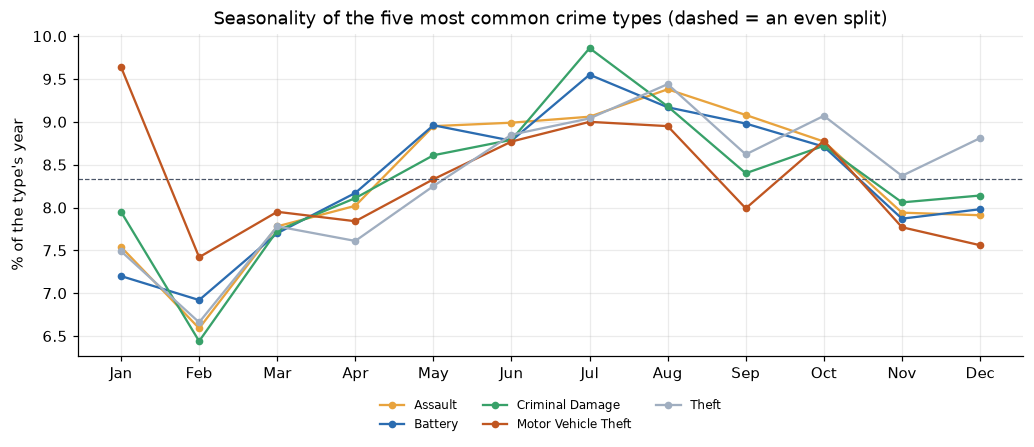

In [11]:
season = q("""
WITH top_types AS (
    SELECT primary_type FROM crimes GROUP BY primary_type ORDER BY COUNT(*) DESC LIMIT 5
),
monthly AS (
    SELECT primary_type, CAST(strftime('%m', date) AS INT) AS month, COUNT(*) AS n
    FROM crimes
    WHERE primary_type IN (SELECT primary_type FROM top_types)
    GROUP BY primary_type, month
)
SELECT primary_type AS crime_type, month, n,
       ROUND(100.0 * n / SUM(n) OVER (PARTITION BY primary_type), 2) AS share_of_year_pct
FROM monthly
ORDER BY primary_type, month
""")

wide = season.pivot(index="month", columns="crime_type", values="share_of_year_pct")
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for col, color in zip(wide.columns, [AMBER, BLUE, "#38a169", "#c05621", GREY]):
    ax.plot(wide.index, wide[col], marker="o", ms=4, label=col.title(), color=color)
ax.axhline(100 / 12, color="#4a5568", ls="--", lw=0.8)
ax.set_xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_ylabel("% of the type's year")
ax.set_title("Seasonality of the five most common crime types (dashed = an even split)")
ax.legend(frameon=False, ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1))
fig.tight_layout()
plt.show()

## What the queries say

- **A typical day has about 723 reported incidents** (263,850 in the year). Theft is the largest type at 21.8%, then battery (16.8%), criminal damage (11.4%) and motor vehicle theft (11.1%).
- **Arrest rates differ enormously by type.** Narcotics ends in an arrest 97.6% of the time and weapons violations 58%, because those offences are usually recorded *because* police made contact. Theft is 5.0%, criminal damage 3.1% and motor vehicle theft 2.7%. Battery is the most domestic type: 54% of battery reports are domestic.
- **The clock has a pattern, and a data quirk.** The quietest weekday-hour is Thursday at 4 a.m. (613 incidents over the year) and the evening hours are busy every day. Midnight holds 7.3% of all incidents, well above an even 4.2%, and noon shows a similar bright column. This looks like default times being used when the exact time of an incident is unknown (an interpretation, the data does not say so).
- **Two kinds of neighbourhood.** Austin has the most incidents (12,701). Battery is the most common crime in Austin, South Shore, North Lawndale, Humboldt Park, Auburn Gresham and Greater Grand Crossing, while theft dominates in the Loop (39% of its incidents), Near North Side (39%), Near West Side and West Town. These are raw counts, not per-resident rates, and the central areas have large daytime populations.
- **Thefts happen on the street first** (27.4%), then in apartments (12.8%), small retail stores (7.6%) and residences (7.6%).
- **The unusual days are New Year's Day and the 1st of the month.** 1 January had 1,157 incidents, 6.2 standard deviations above the average, and 25 December was the quietest day at 533. All five of the other unusually busy days are first-of-the-month dates. On the 1st the average is 860 incidents against 717 on other days, and most of the extra comes from deceptive practice (113 a day against 46), with midnight timestamps three times as common (10.1% against 3.5%). That fits the idea that offences with an unknown date get logged on the 1st, though the data cannot confirm it.
- **Summer runs hot.** The longest streak of days above the median lasted 42 days, from 3 July to 13 August. Assault, battery, criminal damage and theft all peak in July or August (about 9.4-9.9% of the year's count) and bottom out in February (6.4-6.9%). Motor vehicle theft is the exception: its peak month is January (9.6%).

**Limits:** these are reported incidents, so they reflect reporting and policing as well as crime; the neighbourhood comparison uses raw counts because the data has no population figures; this is one year, so there is no trend.

**Techniques covered:** window frames (moving average), `RANK`, `ROW_NUMBER` per group, running totals, a z-score built from window aggregates, gaps and islands, conditional aggregation and pivots.
